In [13]:
import altair as alt 
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.insert(0, '..')

from dataloader import load_df, load_sensitivity, PARAMS, load_sensitivity_perframe, load_perframe_pervalue, PARAM_LABELS, RESOLUTION_LABELS
df          = load_df("../dataset.json")
sensitivity = load_sensitivity("../dataset.json")
sensitivity_perframe = load_sensitivity_perframe("../dataset.json")
df_pervalue = load_perframe_pervalue("../dataset.json", 5,5)


/Users/mariasilva/Documents/PerceptualTAA/parameter_analysis/../dataloader.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_center_group)
/Users/mariasilva/Documents/PerceptualTAA/parameter_analysis/../dataloader.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_center_group)
/Users/mariasilva/Documents/PerceptualTAA/parameter_analysis/../dataloader.py:224: FutureWarning: DataFrameGroupBy.app

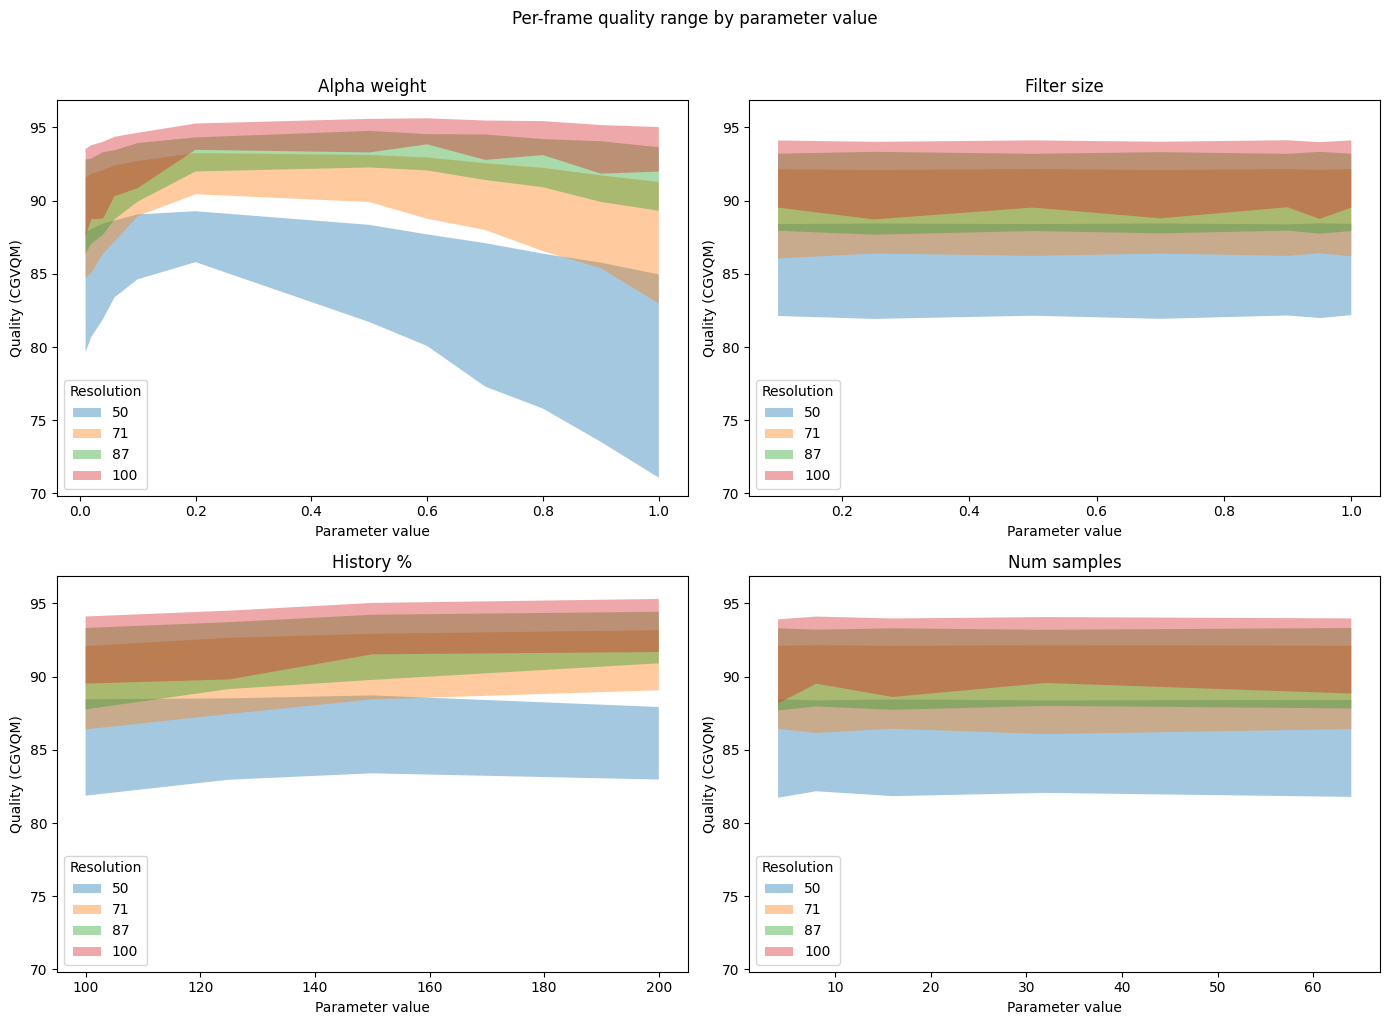

In [14]:
# For each (resolution, parameter, value), get mean best and worst quality across scenes
agg = df_pervalue.groupby(['resolution', 'parameter', 'value']).agg(
    mean_best=('quality_best', 'mean'),
    mean_worst=('quality_worst', 'mean'),
).reset_index()

agg['range'] = agg['mean_best'] - agg['mean_worst']

y_min = agg[['mean_best', 'mean_worst']].min().min()
y_max = agg[['mean_best', 'mean_worst']].max().max()
margin = (y_max - y_min) * 0.05  # 5% padding


def plot_range_only(df, param, ax):
    df_param = df[df['parameter'] == param]
    for res, grp in df_param.groupby('resolution'):
        ax.fill_between(grp['value'], grp['mean_worst'], grp['mean_best'], alpha=0.4, label=res)
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Quality (CGVQM)')
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.legend(title='Resolution')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, param in zip(axes.flatten(), PARAMS):
    plot_range_only(agg, param, ax)
plt.suptitle('Per-frame quality range by parameter value', y=1.02)
plt.tight_layout()
plt.show()

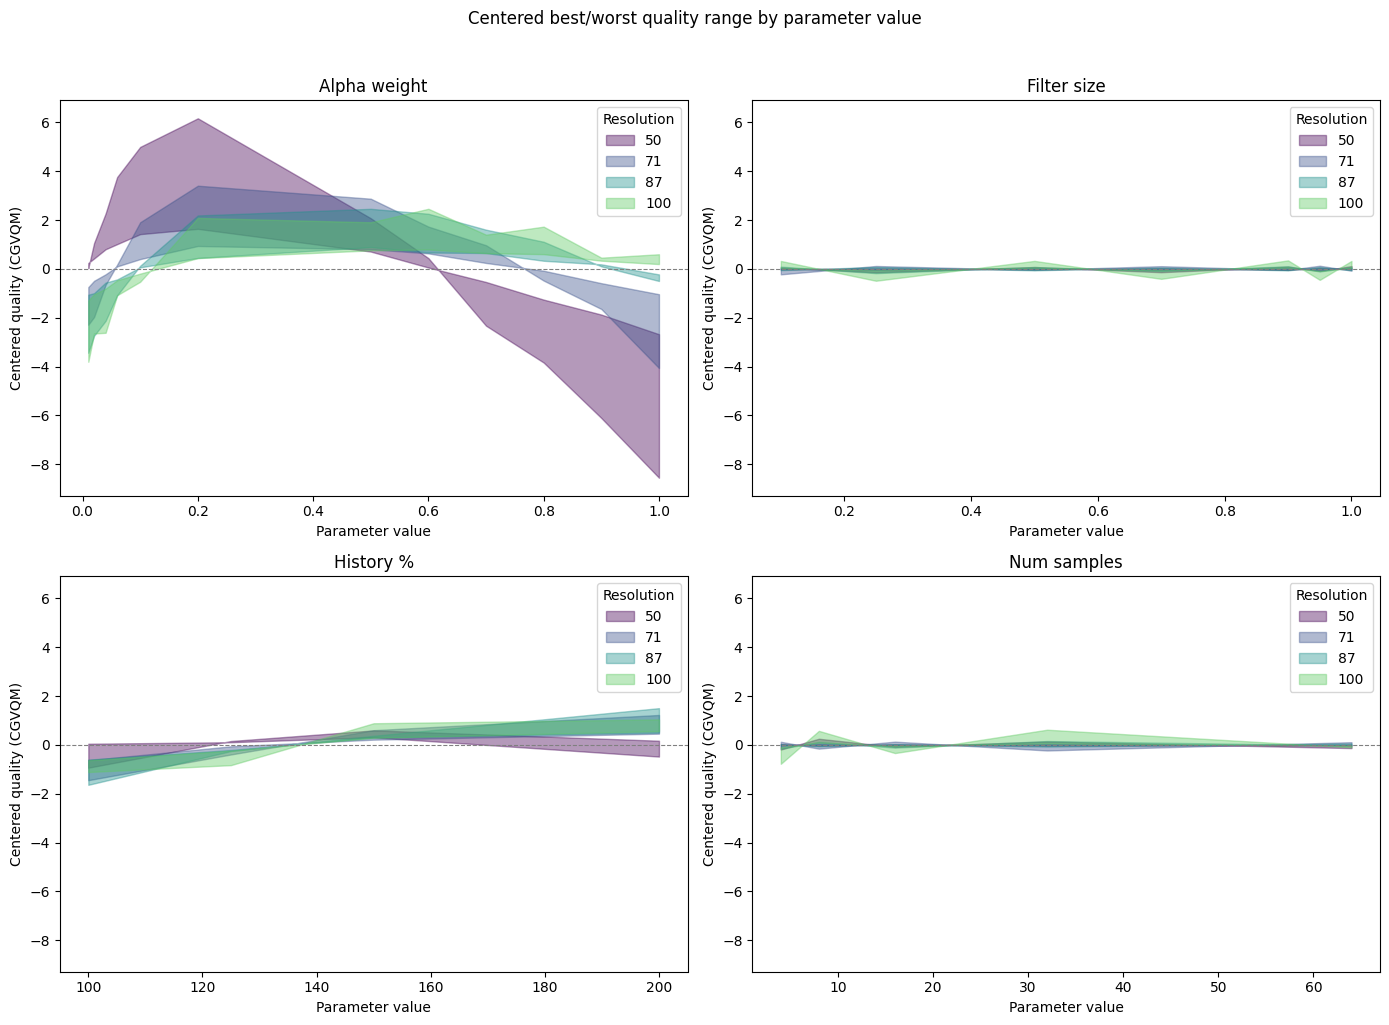

In [15]:
# Compute agg with scene preserved
agg = df_pervalue.groupby(['scene', 'resolution', 'parameter', 'value']).agg(
    mean_best=('quality_best', 'mean'),
    mean_worst=('quality_worst', 'mean'),
).reset_index()

agg['mean_quality'] = (agg['mean_best'] + agg['mean_worst']) / 2

agg['centered_quality'] = agg.groupby(
    ['scene', 'resolution', 'parameter'])['mean_quality'].transform(
    lambda x: x - x.mean())

agg['centered_best'] = agg.groupby(
    ['scene', 'resolution', 'parameter'])['mean_best'].transform(
    lambda x: x - x.mean())

agg['centered_worst'] = agg.groupby(
    ['scene', 'resolution', 'parameter'])['mean_worst'].transform(
    lambda x: x - x.mean())

# Average across scenes
plot_df = agg.groupby(['resolution', 'parameter', 'value']).agg(
    centered_best=('centered_best', 'mean'),
    centered_worst=('centered_worst', 'mean'),
).reset_index()

import matplotlib.pyplot as plt

y_min = plot_df[['centered_best', 'centered_worst']].min().min()
y_max = plot_df[['centered_best', 'centered_worst']].max().max()
margin = (y_max - y_min) * 0.05

def plot_centered_range(df, param, ax):
    df_param = df[df['parameter'] == param]
    for i, (res, grp) in enumerate(df_param.groupby('resolution')):
        color = plt.cm.viridis(i / 4)
        ax.fill_between(grp['value'], grp['centered_worst'], grp['centered_best'],
                        alpha=0.4, color=color, label=res)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Centered quality (CGVQM)')
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.legend(title='Resolution')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, param in zip(axes.flatten(), PARAMS):
    plot_centered_range(plot_df, param, ax)
plt.suptitle('Centered best/worst quality range by parameter value', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
centered_ranges = agg.groupby(
    ['scene', 'resolution', 'parameter'])['centered_quality'].apply(
    lambda x: x.max() - x.min()).reset_index()
centered_ranges.columns = ['scene', 'resolution', 'parameter', 'centered_range']

table = centered_ranges.groupby(
    ['resolution', 'parameter'])['centered_range'].mean().unstack('parameter')

table = table.sort_values('resolution', ascending=False)
print(table.round(2))

parameter   alpha_weight  filter_size  hist_percent  num_samples
resolution                                                      
100                 4.57         0.53          2.09         0.86
87                  4.98         0.55          2.21         0.58
71                  6.40         0.51          2.28         0.56
50                 10.01         0.43          2.38         0.52


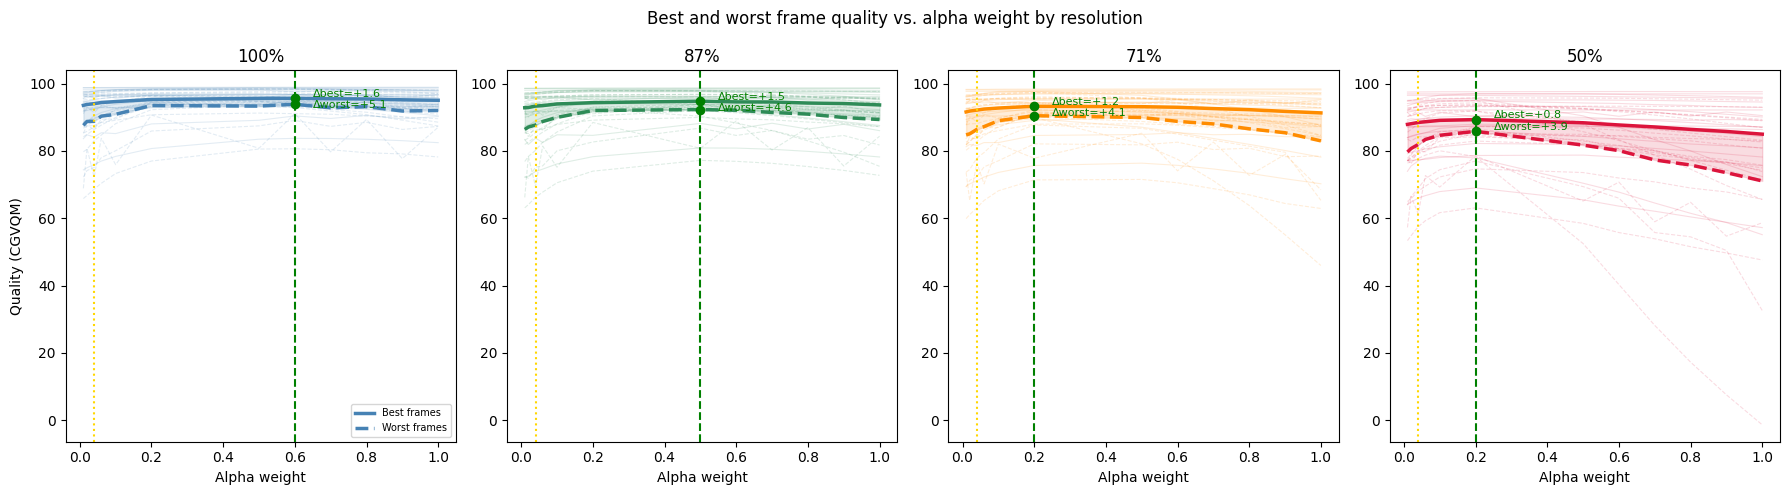

In [17]:
y_min = agg[['mean_best', 'mean_worst']].min().min()
y_max = agg[['mean_best', 'mean_worst']].max().max()
margin = (y_max - y_min) * 0.05

RESOLUTIONS = [100, 87, 71, 50]
COLORS = {100: 'steelblue', 87: 'seagreen', 71: 'darkorange', 50: 'crimson'}
DEFAULT_VALS = {
    'alpha_weight': 0.04,
    'filter_size': 1.0,
    'hist_percent': 100,
    'num_samples': 8
}

def plot_best_worst_by_res(agg, param, axes):
    df_param = agg[agg['parameter'] == param].copy()
    default_val = DEFAULT_VALS[param]

    for ax, res in zip(axes, RESOLUTIONS):
        df_res = df_param[df_param['resolution'] == res].sort_values('value')
        color = COLORS[res]

        # Plot individual scene thin lines
        for scene in df_res['scene'].unique():
            scene_df = df_res[df_res['scene'] == scene].sort_values('value')
            ax.plot(scene_df['value'], scene_df['mean_best'],
                    color=color, alpha=0.15, linewidth=0.8)
            ax.plot(scene_df['value'], scene_df['mean_worst'],
                    color=color, alpha=0.15, linewidth=0.8, linestyle='--')

        # Mean across scenes
        grp = df_res.groupby('value')[['mean_best', 'mean_worst', 'mean_quality']].mean().reset_index()

        ax.plot(grp['value'], grp['mean_best'],
                color=color, linewidth=2.5, label='Best frames')
        ax.plot(grp['value'], grp['mean_worst'],
                color=color, linewidth=2.5, linestyle='--', label='Worst frames')
        ax.fill_between(grp['value'], grp['mean_worst'], grp['mean_best'],
                        color=color, alpha=0.15)

        # Default line
        ax.axvline(default_val, color='gold', linewidth=1.5, linestyle=':')

        # Optimal = value with highest mean_best
        opt_idx = grp['mean_best'].idxmax()
        opt_val = grp.loc[opt_idx, 'value']
        opt_best = grp.loc[opt_idx, 'mean_best']
        opt_worst = grp.loc[opt_idx, 'mean_worst']

        # Default quality
        default_row = grp.iloc[(grp['value'] - default_val).abs().argsort().iloc[:1]]
        default_best = default_row['mean_best'].values[0]
        default_worst = default_row['mean_worst'].values[0]

        gain_best = opt_best - default_best
        gain_worst = opt_worst - default_worst

        ax.axvline(opt_val, color='green', linewidth=1.5, linestyle='--')
        ax.scatter([opt_val], [opt_best], color='green', zorder=5)
        ax.scatter([opt_val], [opt_worst], color='green', zorder=5)
        ax.annotate(f'Δbest=+{gain_best:.1f}\nΔworst=+{gain_worst:.1f}',
                    xy=(opt_val, opt_best),
                    xytext=(opt_val + 0.05, opt_best - 3),
                    fontsize=8, color='green')

        ax.set_title(f'{res}%')
        ax.set_xlabel(PARAM_LABELS[param])
        ax.set_ylim(y_min - margin, y_max + margin)
        if ax == axes[0]:
            ax.set_ylabel('Quality (CGVQM)')
            ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
plot_best_worst_by_res(agg, 'alpha_weight', axes)
plt.suptitle('Best and worst frame quality vs. alpha weight by resolution')
plt.tight_layout()
plt.show()

In [18]:
# Check what resolution values actually look like
print(agg['resolution'].unique())
print(agg['resolution'].dtype)
print(agg[agg['parameter'] == 'alpha_weight'].head())

[ 50  71  87 100]
int64
       scene  resolution     parameter  value  mean_best  mean_worst  \
0  abandoned          50  alpha_weight   0.01  91.545776   85.545624   
1  abandoned          50  alpha_weight   0.02  91.678758   86.354989   
2  abandoned          50  alpha_weight   0.04  92.083595   88.071844   
3  abandoned          50  alpha_weight   0.06  92.617695   89.563768   
4  abandoned          50  alpha_weight   0.10  92.898969   91.206772   

   mean_quality  centered_quality  centered_best  centered_worst  
0     88.545700          0.664235      -0.526120        1.854589  
1     89.016873          1.135408      -0.393138        2.663954  
2     90.077720          2.196254       0.011699        4.380809  
3     91.090732          3.209266       0.545799        5.872733  
4     92.052870          4.171405       0.827073        7.515737  


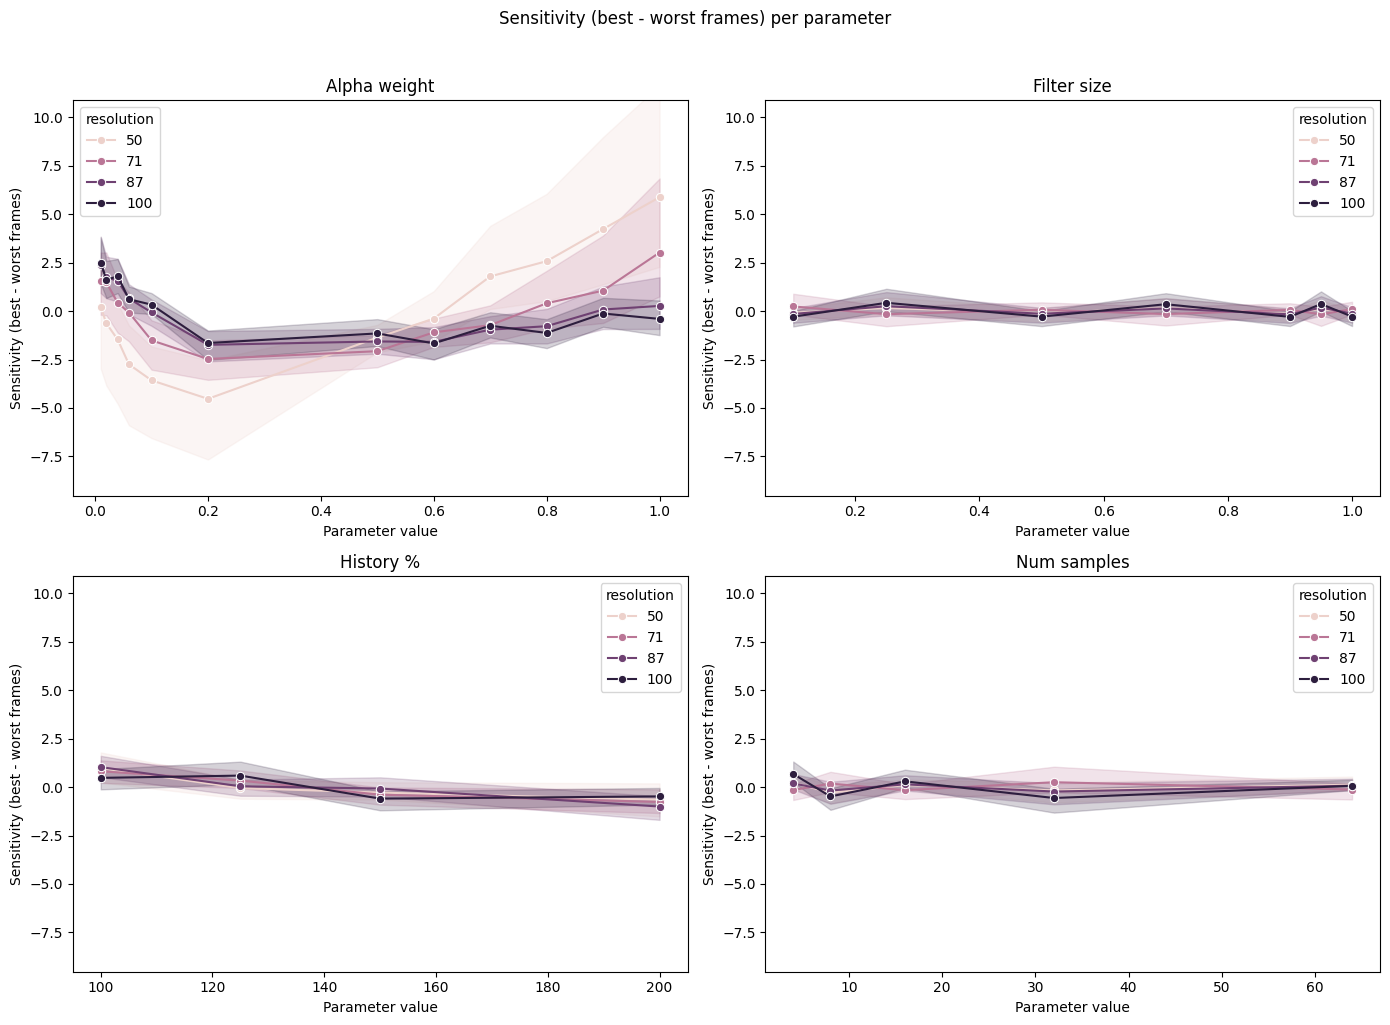

In [19]:
df_pervalue['sensitivity'] = df_pervalue['quality_best'] - df_pervalue['quality_worst']
df_pervalue['centered_sensitivity'] = df_pervalue.groupby(
    ['scene', 'resolution', 'parameter'])['sensitivity'].transform(
    lambda x: x - x.mean())


agg_stats = df_pervalue.groupby(['parameter', 'value', 'resolution'])['centered_sensitivity'].agg(['mean', 'std']).reset_index()

y_min = (agg_stats['mean']).min() - 5
y_max = (agg_stats['mean']).max() + 5

def plot_sensitivity_by_param(df_pervalue, param, ax):
    df_param = df_pervalue[df_pervalue['parameter'] == param]
    sns.lineplot(
        data=df_param,
        x='value',
        y='centered_sensitivity',
        hue='resolution',
        marker='o',
        ax=ax
    )
    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Sensitivity (best - worst frames)')
    ax.set_ylim(y_min, y_max)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, param in zip(axes.flatten(), PARAMS):
    plot_sensitivity_by_param(df_pervalue, param, ax)

plt.suptitle('Sensitivity (best - worst frames) per parameter', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Compute centered versions of all three metrics
for col in ['quality_best', 'quality_worst']:
    agg[f'centered_{col}'] = agg.groupby(
        ['scene', 'resolution', 'parameter'])[col].transform(
        lambda x: x - x.mean())

# Also need centered mean quality from df (your existing Fig 6 data)
df_centered = df.copy()
df_centered['centered_quality'] = df_centered.groupby(
    ['scene', 'resolution', 'parameter'])['quality'].transform(
    lambda x: x - x.mean())

# Average across scenes
plot_agg = agg.groupby(['resolution', 'parameter', 'value'])[
    ['centered_quality_best', 'centered_quality_worst']].mean().reset_index()

plot_mean = df_centered.groupby(['resolution', 'parameter', 'value'])[
    'centered_quality'].mean().reset_index()

DEFAULT_VALS = {
    'alpha_weight': 0.04,
    'filter_size': 1.0,
    'hist_percent': 100,
    'num_samples': 8
}

y_min = min(plot_agg['centered_quality_worst'].min(), 
            plot_mean['centered_quality'].min())
y_max = max(plot_agg['centered_quality_best'].max(),
            plot_mean['centered_quality'].max())
margin = (y_max - y_min) * 0.05

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

def plot_three_lines(plot_agg, plot_mean, param, ax):
    df_agg  = plot_agg[plot_agg['parameter'] == param]
    df_mean = plot_mean[plot_mean['parameter'] == param]
    default_val = DEFAULT_VALS[param]

    for res in RESOLUTIONS:
        color = RESOLUTION_COLORS[res]
        res_agg  = df_agg[df_agg['resolution'] == res].sort_values('value')
        res_mean = df_mean[df_mean['resolution'] == res].sort_values('value')

        # Three lines
        ax.plot(res_agg['value'],  res_agg['centered_quality_best'],
                color=color, linewidth=2, linestyle='-',  label=f'{res}% best')
        ax.plot(res_mean['value'], res_mean['centered_quality'],
                color=color, linewidth=2, linestyle='-.',  label=f'{res}% mean')
        ax.plot(res_agg['value'],  res_agg['centered_quality_worst'],
                color=color, linewidth=2, linestyle='--', label=f'{res}% worst')

        ax.fill_between(res_agg['value'],
                        res_agg['centered_quality_worst'],
                        res_agg['centered_quality_best'],
                        color=color, alpha=0.08)

        # Optimal = max of mean quality
        opt_idx = res_mean['centered_quality'].idxmax()
        opt_val = res_mean.loc[opt_idx, 'value']

        # Default vs optimal for all three metrics
        def_agg  = res_agg.iloc[(res_agg['value'] - default_val).abs().argsort().iloc[:1]]
        opt_agg  = res_agg.iloc[(res_agg['value'] - opt_val).abs().argsort().iloc[:1]]
        def_mean = res_mean.iloc[(res_mean['value'] - default_val).abs().argsort().iloc[:1]]
        opt_mean = res_mean.iloc[(res_mean['value'] - opt_val).abs().argsort().iloc[:1]]

        gain_best  = opt_agg['centered_quality_best'].values[0]  - def_agg['centered_quality_best'].values[0]
        gain_mean  = opt_mean['centered_quality'].values[0]       - def_mean['centered_quality'].values[0]
        gain_worst = opt_agg['centered_quality_worst'].values[0] - def_agg['centered_quality_worst'].values[0]

        # Mark optimal
        ax.axvline(opt_val, color=color, linewidth=1, linestyle=':')
        ax.text(opt_val + 0.01, y_min + margin,
                f'B:+{gain_best:.1f}\nM:+{gain_mean:.1f}\nW:+{gain_worst:.1f}',
                fontsize=6, color=color)

    # UE default
    ax.axvline(default_val, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

    ax.set_title(PARAM_LABELS[param])
    ax.set_xlabel('Parameter value')
    ax.set_ylim(y_min - margin, y_max + margin)
    if ax == axes[0]:
        ax.set_ylabel('Centered quality (CGVQM)')

    # Compact legend showing line styles only
    from matplotlib.lines import Line2D
    style_handles = [
        Line2D([0], [0], color='gray', linewidth=2, linestyle='-',   label='Best frames'),
        Line2D([0], [0], color='gray', linewidth=2, linestyle='-.',  label='Mean quality'),
        Line2D([0], [0], color='gray', linewidth=2, linestyle='--',  label='Worst frames'),
        Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='UE default'),
    ]
    ax.legend(handles=style_handles, fontsize=7)

for ax, param in zip(axes, PARAMS):
    plot_three_lines(plot_agg, plot_mean, param, ax)

plt.suptitle('Best, mean, and worst frame quality by parameter value and resolution', y=1.02)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: quality_best'

In [21]:
# Step 1: prep data
agg2 = df_pervalue.groupby(['scene', 'resolution', 'parameter', 'value']).agg(
    mean_best=('quality_best', 'mean'),
    mean_worst=('quality_worst', 'mean'),
).reset_index()

# Mean quality from existing df — check what columns df has
print(df.columns.tolist())

['scene', 'resolution', 'parameter', 'value', 'score', 'per_frame_errors', 'score_centered']


In [22]:
def build_best_worst_chart(param_name, title):
    # --- prep mean quality (from df) ---
    param_df = df[df['parameter'] == param_name].copy()
    mean_scores = (
        param_df.groupby(['resolution', 'value'])['score']
        .mean().reset_index()
    )

    # --- prep best/worst (from df_pervalue) ---
    param_pv = df_pervalue[df_pervalue['parameter'] == param_name].copy()
    best_worst = (
        param_pv.groupby(['resolution', 'value'])[['quality_best', 'quality_worst']]
        .mean().reset_index()
    )

    # merge all three into one df
    merged = mean_scores.merge(best_worst, on=['resolution', 'value'], how='left')
    merged['resolution_label'] = merged['resolution'].map(RESOLUTION_LABELS)

    # optimal = value with highest mean score per resolution
    optimal_vals = (
        merged.loc[merged.groupby('resolution')['score'].idxmax(), ['resolution', 'value']]
        .rename(columns={'value': 'opt_val'})
    )
    merged = merged.merge(optimal_vals, on='resolution', how='left')

    default_val = DEFAULT_VALS[param_name]

    # global y scale across all three metrics
    y_min = min(merged['quality_worst'].min(), merged['score'].min()) - 1
    y_max = max(merged['quality_best'].max(), merged['score'].max()) + 1
    y_scale = alt.Scale(domain=[y_min, y_max], zero=False)

    panels = []
    for res_label, res_int in zip(res_order, [100, 87, 71, 50]):
        ms = merged[merged['resolution_label'] == res_label].copy()

        opt_val  = ms['opt_val'].values[0]
        opt_row  = ms.iloc[(ms['value'] - opt_val).abs().argsort().iloc[:1]]
        dft_row  = ms.iloc[(ms['value'] - default_val).abs().argsort().iloc[:1]]

        delta_mean  = opt_row['score'].values[0]        - dft_row['score'].values[0]
        delta_best  = opt_row['quality_best'].values[0] - dft_row['quality_best'].values[0]
        delta_worst = opt_row['quality_worst'].values[0]- dft_row['quality_worst'].values[0]

        sign = lambda x: '+' if x >= 0 else ''

        annotation_data = pd.DataFrame({
            'value': [opt_val],
            'score': [opt_row['score'].values[0]],
            'label': [
                f"Δmean={sign(delta_mean)}{delta_mean:.2f}\n"
                f"Δbest={sign(delta_best)}{delta_best:.2f}\n"
                f"Δworst={sign(delta_worst)}{delta_worst:.2f}"
            ]
        })

        # melt into long format for the 3 lines
        ms_long = ms.melt(
            id_vars=['resolution', 'resolution_label', 'value', 'opt_val'],
            value_vars=['score', 'quality_best', 'quality_worst'],
            var_name='metric', value_name='quality'
        )
        metric_dash = alt.Scale(
            domain=['score', 'quality_best', 'quality_worst'],
            range=[[1, 0], [4, 2], [2, 2]]
        )
        metric_labels = {
            'score': 'Mean', 
            'quality_best': 'Best frames', 
            'quality_worst': 'Worst frames'
        }
        ms_long['metric_label'] = ms_long['metric'].map(metric_labels)

        color = res_colors[res_order.index(res_label)]

        # 3 lines
        lines = alt.Chart(ms_long).mark_line(strokeWidth=2).encode(
            x=alt.X('value:Q', title=PARAM_LABELS[param_name]),
            y=alt.Y('quality:Q',
                    title='CGVQM' if res_label == '100%' else '',
                    scale=y_scale),
            strokeDash=alt.StrokeDash('metric_label:N',
                scale=alt.Scale(
                    domain=['Mean', 'Best frames', 'Worst frames'],
                    range=[[1, 0], [4, 2], [2, 2]]
                ),
                legend=alt.Legend(title='Metric') if res_label == '100%' else None
            ),
            color=alt.value(color),
        )

        # default vertical line
        dft_rule = alt.Chart(dft_row).mark_rule(
            strokeDash=[4, 2], strokeWidth=2, color='#f5c400'
        ).encode(x='value:Q')

        # optimal vertical line
        opt_rule = alt.Chart(opt_row).mark_rule(
            strokeDash=[4, 2], strokeWidth=2, color="#000000"
        ).encode(x='value:Q')

        # annotation text
        annotation = alt.Chart(annotation_data).mark_text(
            align='left', dx=6, dy=0,
            fontSize=9, fontWeight='bold', color="#000000",
            lineBreak='\n'
        ).encode(
            x='value:Q',
            y=alt.Y('score:Q', scale=y_scale),
            text='label:N'
        )

        panel = (lines + dft_rule + opt_rule + annotation).properties(
            width=180, height=180, title=res_label
        )
        panels.append(panel)

    return alt.hconcat(*panels).properties(title=title)

# Build all 4 parameter charts stacked vertically
full_chart = alt.vconcat(*[
    build_best_worst_chart(p, PARAM_LABELS[p]) for p in PARAMS
]).resolve_scale(y='independent')

full_chart

alt.VConcatChart(...)

In [23]:
def build_panel(param_name, res_label, res_int):
    param_df = df[df['parameter'] == param_name].copy()
    mean_scores = (
        param_df.groupby(['resolution', 'value'])['score']
        .mean().reset_index()
    )
    param_pv = df_pervalue[df_pervalue['parameter'] == param_name].copy()
    best_worst = (
        param_pv.groupby(['resolution', 'value'])[['quality_best', 'quality_worst']]
        .mean().reset_index()
    )
    merged = mean_scores.merge(best_worst, on=['resolution', 'value'], how='left')
    merged['resolution_label'] = merged['resolution'].map(RESOLUTION_LABELS)

    optimal_vals = (
        merged.loc[merged.groupby('resolution')['score'].idxmax(), ['resolution', 'value']]
        .rename(columns={'value': 'opt_val'})
    )
    merged = merged.merge(optimal_vals, on='resolution', how='left')

    default_val = DEFAULT_VALS[param_name]

    y_min = min(merged['quality_worst'].min(), merged['score'].min()) - 1
    y_max = max(merged['quality_best'].max(), merged['score'].max()) + 1
    y_scale = alt.Scale(domain=[y_min, y_max], zero=False)

    ms = merged[merged['resolution_label'] == res_label].copy()
    opt_val = ms['opt_val'].values[0]
    opt_row = ms.iloc[(ms['value'] - opt_val).abs().argsort().iloc[:1]]
    dft_row = ms.iloc[(ms['value'] - default_val).abs().argsort().iloc[:1]]

    delta_mean  = opt_row['score'].values[0]         - dft_row['score'].values[0]
    delta_best  = opt_row['quality_best'].values[0]  - dft_row['quality_best'].values[0]
    delta_worst = opt_row['quality_worst'].values[0] - dft_row['quality_worst'].values[0]

    sign = lambda x: '+' if x >= 0 else ''
    annotation_data = pd.DataFrame({
        'value': [opt_val],
        'score': [opt_row['score'].values[0]],
        'label': [
            f"Δmean={sign(delta_mean)}{delta_mean:.2f}\n"
            f"Δbest={sign(delta_best)}{delta_best:.2f}\n"
            f"Δworst={sign(delta_worst)}{delta_worst:.2f}"
        ]
    })

    ms_long = ms.melt(
        id_vars=['resolution', 'resolution_label', 'value', 'opt_val'],
        value_vars=['score', 'quality_best', 'quality_worst'],
        var_name='metric', value_name='quality'
    )
    metric_labels = {
        'score': 'Mean',
        'quality_best': 'Best frames',
        'quality_worst': 'Worst frames'
    }
    ms_long['metric_label'] = ms_long['metric'].map(metric_labels)
    color = res_colors[res_order.index(res_label)]

    # title only on first row, y axis label only on first column
    show_y     = res_label == '100%'
    panel_title = f"{PARAM_LABELS[param_name]} — {res_label}" if res_label == '100%' \
                  else res_label

    lines = alt.Chart(ms_long).mark_line(strokeWidth=2).encode(
        x=alt.X('value:Q', title=PARAM_LABELS[param_name]),
        y=alt.Y('quality:Q',
                title='CGVQM' if show_y else '',
                scale=y_scale),
        strokeDash=alt.StrokeDash('metric_label:N',
            scale=alt.Scale(
                domain=['Mean', 'Best frames', 'Worst frames'],
                range=[[1, 0], [4, 2], [2, 2]]
            ),
            legend=alt.Legend(title='Metric') if (param_name == PARAMS[0] and res_label == '100%') else None
        ),
        color=alt.value(color),
    )

    dft_rule = alt.Chart(dft_row).mark_rule(
        strokeDash=[4, 2], strokeWidth=2, color='#f5c400'
    ).encode(x='value:Q')

    opt_rule = alt.Chart(opt_row).mark_rule(
        strokeDash=[4, 2], strokeWidth=2, color='#2ca05a'
    ).encode(x='value:Q')

    annotation = alt.Chart(annotation_data).mark_text(
        align='left', dx=6, dy=0,
        fontSize=9, fontWeight='bold', color='#2ca05a',
        lineBreak='\n'
    ).encode(
        x='value:Q',
        y=alt.Y('score:Q', scale=y_scale),
        text='label:N'
    )

    return (lines + dft_rule + opt_rule + annotation).properties(
        width=180, height=180, title=panel_title
    )

# Build all 16 panels
all_panels = []
for param in PARAMS:
    for res_label in res_order:
        res_int = int(res_label.replace('%', ''))
        all_panels.append(build_panel(param, res_label, res_int))

full_chart = alt.concat(*all_panels, columns=4).resolve_scale(
    y='independent',
    x='independent'
)

full_chart

alt.ConcatChart(...)

In [24]:
from dataloader import load_df, load_sensitivity, PARAMS, load_sensitivity_perframe, load_perframe_pervalue, PARAM_LABELS, RESOLUTION_LABELS, RESOLUTIONS

res_order  = ['100%', '75%', '50%', '25%']
res_colors = ['#2a7db5', '#2ca05a', '#e07b3d', '#d4504a']
color_scale = alt.Scale(domain=res_order, range=res_colors)

DEFAULT_VALS = {
    'alpha_weight': 0.04,
    'filter_size':  1.0,
    'hist_percent': 100,
    'num_samples':  8
}

METRIC_COLORS = {
    'Mean':         '#2a7db5',
    'Best frames':  '#2ca05a',
    'Worst frames': '#d4504a',
}

def build_panel(param_name, res_label, res_int):
    param_df = df[df['parameter'] == param_name].copy()
    mean_scores = (
        param_df.groupby(['resolution', 'value'])['score']
        .mean().reset_index()
    )
    param_pv = df_pervalue[df_pervalue['parameter'] == param_name].copy()
    best_worst = (
        param_pv.groupby(['resolution', 'value'])[['quality_best', 'quality_worst']]
        .mean().reset_index()
    )
    merged = mean_scores.merge(best_worst, on=['resolution', 'value'], how='left')
    merged['resolution_label'] = merged['resolution'].map(RESOLUTION_LABELS)
    optimal_vals = (
        merged.loc[merged.groupby('resolution')['score'].idxmax(), ['resolution', 'value']]
        .rename(columns={'value': 'opt_val'})
    )
    merged = merged.merge(optimal_vals, on='resolution', how='left')
    default_val = DEFAULT_VALS[param_name]

    y_min = min(merged['quality_worst'].min(), merged['score'].min()) - 1
    y_max = max(merged['quality_best'].max(), merged['score'].max()) + 1
    y_scale = alt.Scale(domain=[y_min, y_max], zero=False)

    ms = merged[merged['resolution_label'] == res_label].copy()
    opt_val = ms['opt_val'].values[0]
    opt_row = ms.iloc[(ms['value'] - opt_val).abs().argsort().iloc[:1]]
    dft_row = ms.iloc[(ms['value'] - default_val).abs().argsort().iloc[:1]]

    delta_mean  = opt_row['score'].values[0]         - dft_row['score'].values[0]
    delta_best  = opt_row['quality_best'].values[0]  - dft_row['quality_best'].values[0]
    delta_worst = opt_row['quality_worst'].values[0] - dft_row['quality_worst'].values[0]

    sign = lambda x: '+' if x >= 0 else ''

    # Rightmost x value for label placement
    x_right = ms['value'].max()
    right_row = ms.iloc[(ms['value'] - x_right).abs().argsort().iloc[:1]]

    dy_values = [-8, 0, 8] if param_name != 'alpha_weight' else [-10, 0, 10]

    annotation_data = pd.DataFrame({
        'value': [x_right, x_right, x_right],
        'quality': [
            right_row['quality_best'].values[0],
            right_row['score'].values[0],
            right_row['quality_worst'].values[0],
        ],
        'label': [
            f"Δbest={sign(delta_best)}{delta_best:.2f}",
            f"Δmean={sign(delta_mean)}{delta_mean:.2f}",
            f"Δworst={sign(delta_worst)}{delta_worst:.2f}",
        ],
        'color': [
            METRIC_COLORS['Best frames'],
            METRIC_COLORS['Mean'],
            METRIC_COLORS['Worst frames'],
        ],
        'dy': dy_values
    })

    ms_long = ms.melt(
        id_vars=['resolution', 'resolution_label', 'value', 'opt_val'],
        value_vars=['score', 'quality_best', 'quality_worst'],
        var_name='metric', value_name='quality'
    )
    metric_labels = {
        'score':         'Mean',
        'quality_best':  'Best frames',
        'quality_worst': 'Worst frames'
    }
    ms_long['metric_label'] = ms_long['metric'].map(metric_labels)
    show_y = res_label == '100%'
    show_legend = (param_name == PARAMS[0] and res_label == '100%')

    lines = alt.Chart(ms_long).mark_line(strokeWidth=2).encode(
        x=alt.X('value:Q', title=PARAM_LABELS[param_name]),
        y=alt.Y('quality:Q',
                title='CGVQM' if show_y else '',
                scale=y_scale),
        strokeDash=alt.StrokeDash('metric_label:N',
            scale=alt.Scale(
                domain=['Mean', 'Best frames', 'Worst frames'],
                range=[[1, 0], [4, 2], [2, 2]]
            ),
            legend=alt.Legend(title='Metric') if show_legend else None
        ),
        color=alt.Color('metric_label:N',
            scale=alt.Scale(
                domain=list(METRIC_COLORS.keys()),
                range=list(METRIC_COLORS.values())
            ),
            legend=alt.Legend(title='Metric') if show_legend else None
        ),
    )

    dft_rule = alt.Chart(dft_row).mark_rule(
        strokeDash=[4, 2], strokeWidth=2, color='#e07b3d'
    ).encode(x='value:Q')

    opt_rule = alt.Chart(opt_row).mark_rule(
        strokeDash=[4, 2], strokeWidth=2, color='black'
    ).encode(x='value:Q')

    annotation_layers = [
        alt.Chart(row.to_frame().T).mark_text(
            align='left', dx=6, dy=int(row['dy']),
            fontSize=9, fontWeight='bold',
            color=row['color']
        ).encode(
            x=alt.X('value:Q'),
            y=alt.Y('quality:Q', scale=y_scale),
            text='label:N'
        )
        for _, row in annotation_data.iterrows()
    ]

    return alt.layer(
        lines, dft_rule, opt_rule, *annotation_layers
    ).properties(
        width=180, height=180, title=res_label
    )

# Build all 16 panels
all_panels = []
for param in PARAMS:
    for res_label in res_order:
        res_int = int(res_label.replace('%', ''))
        all_panels.append(build_panel(param, res_label, res_int))

full_chart = alt.concat(*all_panels, columns=4).resolve_scale(
    y='independent',
    x='independent'
).properties(
    title=alt.TitleParams(
        text='Best, mean, and worst frame quality by parameter and resolution',
        subtitle='Black dashed = our recommendation  |  Orange dashed = UE default',
        subtitleFontSize=11,
        subtitleColor='gray'
    )
)

full_chart
full_chart.save('full_chart.png', scale_factor=2.0)